# **PCA and Clustering on Wine Dataset**

The objective of this assignment is to apply Principal Component Analysis, also known as PCA, on the Wine dataset.

# **Importing Required Libraries**

In [27]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

Explanation

In this step, I imported all required libraries.

Pandas and NumPy are used for data handling.
Matplotlib and Seaborn are used for visualization.
StandardScaler is used for feature scaling.
PCA is used for dimensionality reduction.
KMeans is used for clustering.
Silhouette score and Davies-Bouldin score are used to evaluate clustering performance

# **Loading Dataset**

In [28]:
df = pd.read_csv("/content/drive/MyDrive/ASSIGNMENTS/PCA/wine.csv")
df.head()

,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


Explanation

The dataset is loaded using Pandas.
The head() function shows the first five records of the dataset.

# **Dataset Exploration**

In [29]:
df.shape

(178, 14)

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Type             178 non-null    int64  
 1   Alcohol          178 non-null    float64
 2   Malic            178 non-null    float64
 3   Ash              178 non-null    float64
 4   Alcalinity       178 non-null    float64
 5   Magnesium        178 non-null    int64  
 6   Phenols          178 non-null    float64
 7   Flavanoids       178 non-null    float64
 8   Nonflavanoids    178 non-null    float64
 9   Proanthocyanins  178 non-null    float64
 10  Color            178 non-null    float64
 11  Hue              178 non-null    float64
 12  Dilution         178 non-null    float64
 13  Proline          178 non-null    int64  
dtypes: float64(11), int64(3)
memory usage: 19.6 KB


In [31]:
df.describe()

,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,1.938202,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.775035,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,1.000000,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,1.000000,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,2.000000,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,3.000000,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,3.000000,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


Explanation

The shape function shows the number of rows and columns.
The info() function shows column names, data types, and missing values.
The describe() function gives statistical information like mean, minimum, maximum, and standard deviation.

# **Check Missing Values**

In [32]:
df.isnull().sum()

,0
Type,0
Alcohol,0
Malic,0
Ash,0
Alcalinity,0
Magnesium,0
Phenols,0
Flavanoids,0
Nonflavanoids,0
Proanthocyanins,0


In [33]:
df = df.drop_duplicates()
df.shape

(178, 14)

Explanation

This step checks missing values in the dataset.

In this dataset, there are no missing values, so we do not need to apply missing value treatment.

Explanation

Duplicate records can affect analysis and model performance.
So, duplicate values are checked and removed if present.

# **Class Distribution**

In [34]:
df["Type"].value_counts()

,count
Type,
2,71
1,59
3,48


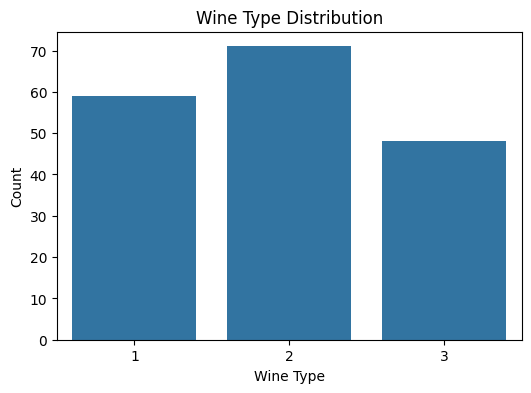

In [35]:
plt.figure(figsize=(6,4))
sns.countplot(x="Type", data=df)
plt.title("Wine Type Distribution")
plt.xlabel("Wine Type")
plt.ylabel("Count")
plt.show()

Explanation

The Type column represents wine classes.
This step checks how many records are present in each wine type.

# **Feature Distribution Using Histograms**

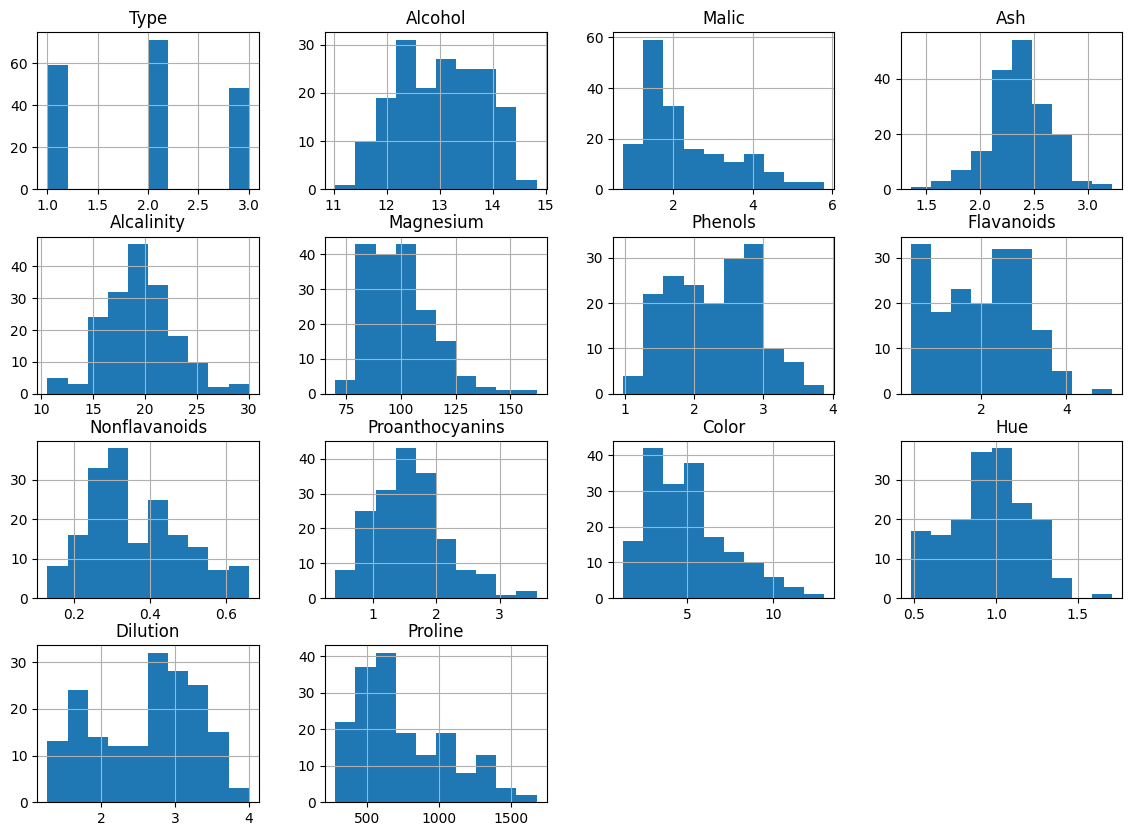

In [36]:
df.hist(figsize=(14,10))
plt.show()

Explanation

Histograms show the distribution of each feature.
They help us understand whether features are normally distributed or skewed.

# **Box Plot for Outlier Detection**

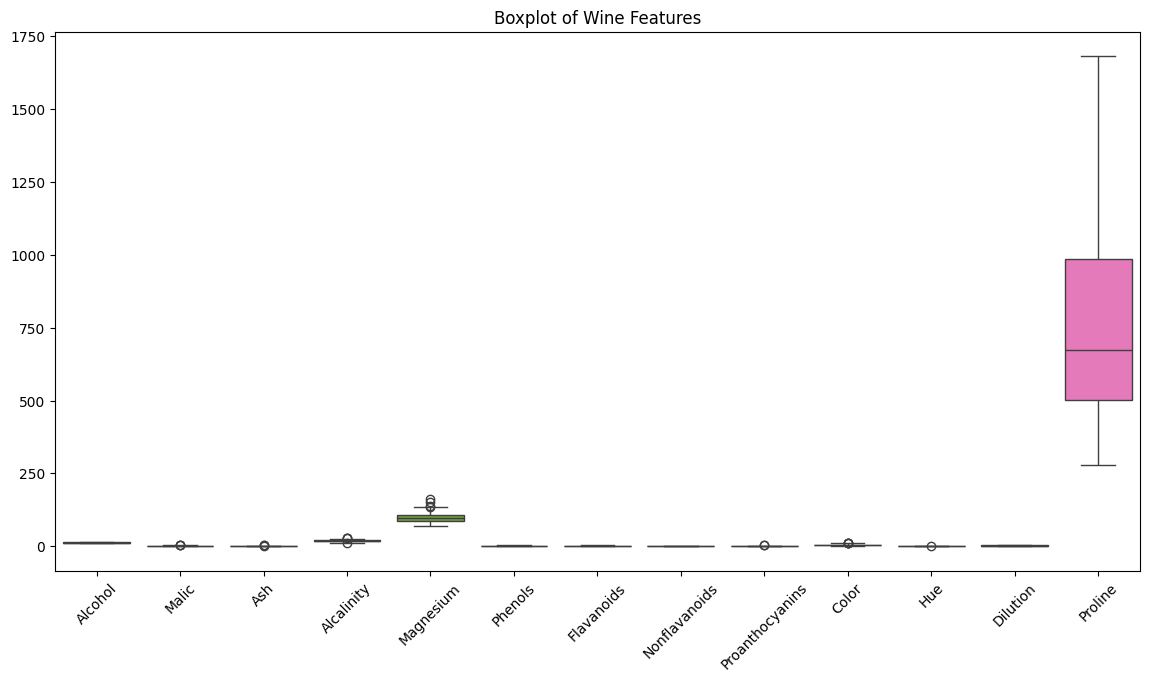

In [37]:
plt.figure(figsize=(14,7))
sns.boxplot(data=df.drop("Type", axis=1))
plt.xticks(rotation=45)
plt.title("Boxplot of Wine Features")
plt.show()

Explanation

Boxplots are used to detect outliers.
Some features may contain high or low extreme values.
These values can affect some algorithms, so it is useful to check them.

# **Correlation Heatmap**

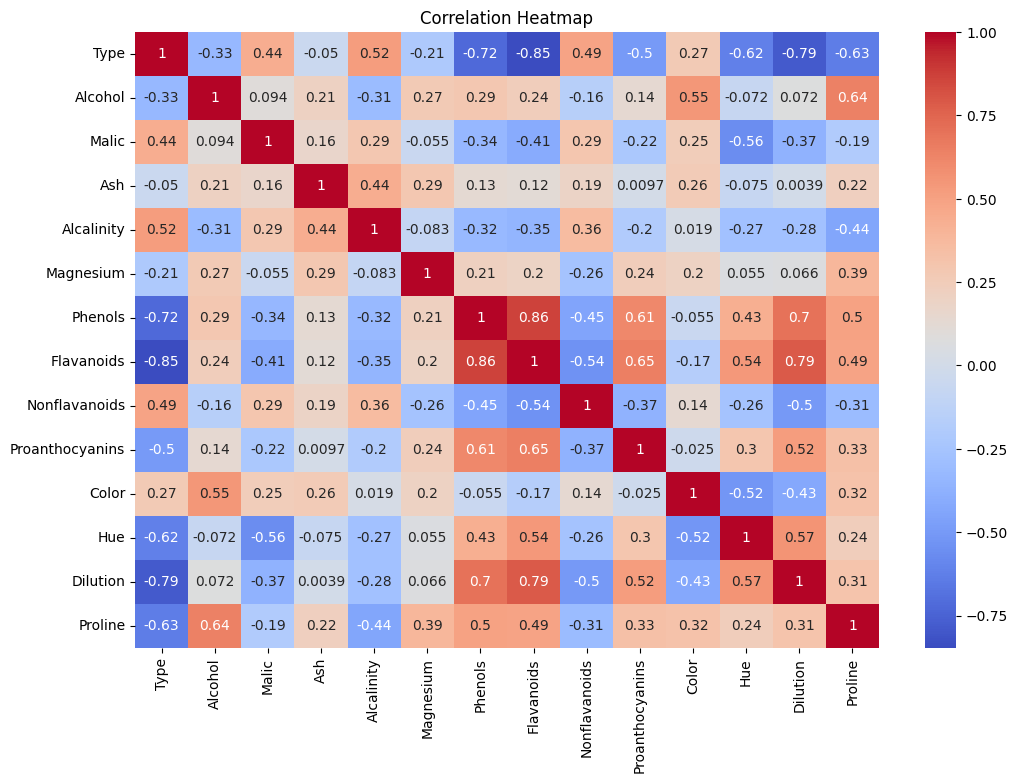

In [38]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

Explanation

The heatmap shows relationships between features.
If two features have high correlation, it means they are strongly related.
PCA is useful when many features are correlated because it converts them into new independent components.

# **Features and Target Column**

In [39]:
X = df.drop("Type", axis=1)
y = df["Type"]

Explanation

Here, X contains all input features.
The Type column is stored separately in y.

For clustering, we mainly use X because clustering is an unsupervised learning method.

# **Standardize the Features**

In [40]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Explanation

PCA is affected by feature scale.
So, standardization is important before applying PCA.

StandardScaler converts the data so that each feature has mean 0 and standard deviation 1.

# **PCA**

In [41]:
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

Explanation

PCA transforms the original features into new features called principal components.
These components contain most of the important information from the original dataset.

# **Explained Variance Ratio**

In [42]:
explained_variance = pca.explained_variance_ratio_
explained_variance

array([0.36198848, 0.1920749 , 0.11123631, 0.0706903 , 0.06563294,
       0.04935823, 0.04238679, 0.02680749, 0.02222153, 0.01930019,
       0.01736836, 0.01298233, 0.00795215])

In [43]:
cumulative_variance = np.cumsum(explained_variance)
cumulative_variance

array([0.36198848, 0.55406338, 0.66529969, 0.73598999, 0.80162293,
       0.85098116, 0.89336795, 0.92017544, 0.94239698, 0.96169717,
       0.97906553, 0.99204785, 1.        ])

Explanation

Explained variance tells us how much information is captured by each principal component.

Cumulative variance shows the total information captured when we combine multiple principal components.

# **Scree Plot**

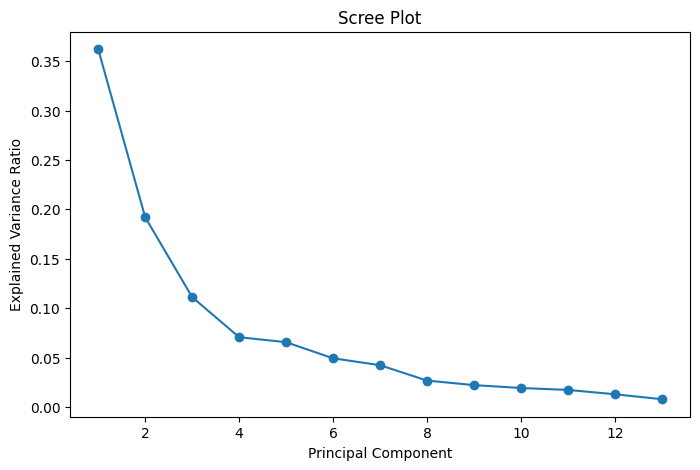

In [44]:
plt.figure(figsize=(8,5))
plt.plot(range(1, len(explained_variance) + 1), explained_variance, marker="o")
plt.title("Scree Plot")
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.show()

Explanation

The scree plot helps us decide how many principal components should be selected.
Components with higher explained variance contain more useful information.

# **Cumulative Explained Variance Plot**

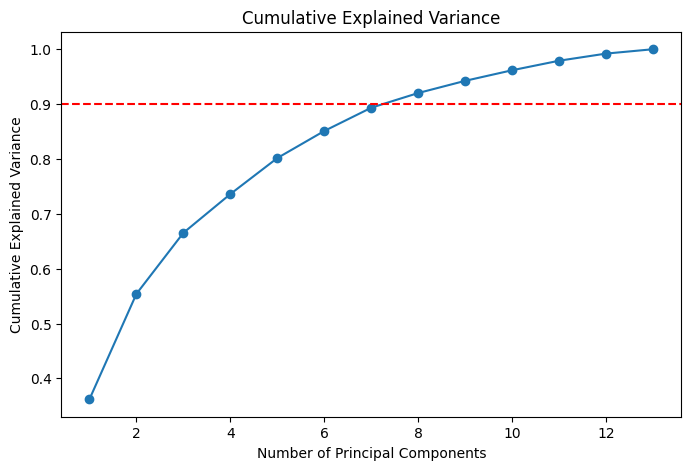

In [45]:
plt.figure(figsize=(8,5))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker="o")
plt.axhline(y=0.90, color="r", linestyle="--")
plt.title("Cumulative Explained Variance")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.show()

Explanation

This graph shows how much total information is captured by different numbers of principal components.

Usually, we select enough components to capture around 90% to 95% variance.

# **Number of Components for 90% Variance**

In [46]:
n_components_90 = np.argmax(cumulative_variance >= 0.90) + 1
n_components_90

np.int64(8)

Explanation

This code finds the minimum number of components needed to capture at least 90% of the information.

In this dataset, around 8 principal components capture nearly 90% variance.

# **PCA with 2 Components for Visualization**

In [47]:
pca_2 = PCA(n_components=2)
X_pca_2 = pca_2.fit_transform(X_scaled)

In [48]:
pca_df = pd.DataFrame(data=X_pca_2, columns=["PC1", "PC2"])
pca_df["Type"] = y
pca_df.head()

,PC1,PC2,Type
0,3.316751,1.443463,1
1,2.209465,-0.333393,1
2,2.516740,1.031151,1
3,3.757066,2.756372,1
4,1.008908,0.869831,1


Explanation

Here, PCA is applied with 2 components.
Two components are useful for visualization because we can plot them on a 2D graph.

# **Visualize PCA Data**

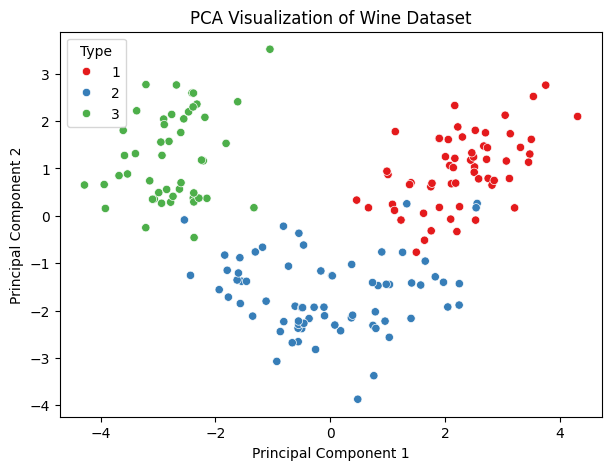

In [49]:
plt.figure(figsize=(7,5))
sns.scatterplot(x="PC1", y="PC2", hue="Type", data=pca_df, palette="Set1")
plt.title("PCA Visualization of Wine Dataset")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

Explanation

This scatter plot shows the dataset after reducing features into two principal components.

Different colors represent different wine types.
If the groups are separated, it means PCA is able to capture useful patterns from the data.

# **K-Means Clustering on Original Data**

In [50]:
kmeans_original = KMeans(n_clusters=3, random_state=42, n_init=10)
original_clusters = kmeans_original.fit_predict(X_scaled)

Explanation

K-Means clustering is applied on the original standardized dataset.

Here, n_clusters=3 is used because the dataset has 3 wine types.

# **Evaluate Clustering on Original Data**

In [51]:
silhouette_original = silhouette_score(X_scaled, original_clusters)
db_original = davies_bouldin_score(X_scaled, original_clusters)

print("Silhouette Score for Original Data:", silhouette_original)
print("Davies-Bouldin Score for Original Data:", db_original)

Silhouette Score for Original Data: 0.2848589191898987
Davies-Bouldin Score for Original Data: 1.3891879777181648


Explanation

Silhouette score measures how well clusters are separated.
Higher silhouette score is better.

Davies-Bouldin score measures similarity between clusters.
Lower Davies-Bouldin score is better.

# **Visualize Original Data Clustering Using PCA Plot**

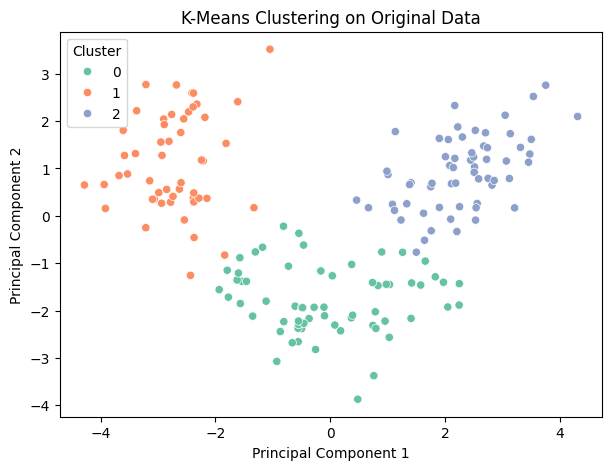

In [52]:
original_cluster_df = pd.DataFrame(X_pca_2, columns=["PC1", "PC2"])
original_cluster_df["Cluster"] = original_clusters

plt.figure(figsize=(7,5))
sns.scatterplot(x="PC1", y="PC2", hue="Cluster", data=original_cluster_df, palette="Set2")
plt.title("K-Means Clustering on Original Data")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

Explanation

The original data has many features, so it cannot be directly visualized in 2D.
That is why PCA components are used only for plotting the original clustering result.

# **K-Means Clustering on PCA Data**

In [53]:
kmeans_pca = KMeans(n_clusters=3, random_state=42, n_init=10)
pca_clusters = kmeans_pca.fit_predict(X_pca_2)

Explanation

In this step, K-Means clustering is applied on PCA-transformed data with 2 principal components.

This helps us compare clustering performance after dimensionality reduction.

# **Evaluate Clustering on PCA Data**

In [54]:
silhouette_pca = silhouette_score(X_pca_2, pca_clusters)
db_pca = davies_bouldin_score(X_pca_2, pca_clusters)

print("Silhouette Score for PCA Data:", silhouette_pca)
print("Davies-Bouldin Score for PCA Data:", db_pca)

Silhouette Score for PCA Data: 0.5610505693103248
Davies-Bouldin Score for PCA Data: 0.5972661544221362


Explanation

Here, clustering performance is evaluated on PCA data.

If the silhouette score is high and Davies-Bouldin score is low, then the clustering result is good.

# **Visualize PCA Clustering Result**

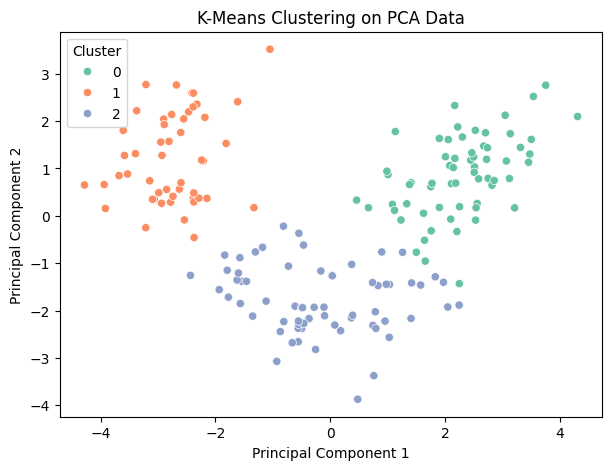

In [55]:
pca_cluster_df = pd.DataFrame(X_pca_2, columns=["PC1", "PC2"])
pca_cluster_df["Cluster"] = pca_clusters

plt.figure(figsize=(7,5))
sns.scatterplot(x="PC1", y="PC2", hue="Cluster", data=pca_cluster_df, palette="Set2")
plt.title("K-Means Clustering on PCA Data")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

Explanation

This plot shows clustering results after reducing the data into two principal components.

It helps us visually understand how the clusters are formed.


# **Compare Original Data and PCA Data Clustering**

In [56]:
comparison = pd.DataFrame({
    "Dataset": ["Original Data", "PCA Data"],
    "Silhouette Score": [silhouette_original, silhouette_pca],
    "Davies-Bouldin Score": [db_original, db_pca]
})

comparison

,Dataset,Silhouette Score,Davies-Bouldin Score
0,Original Data,0.284859,1.389188
1,PCA Data,0.561051,0.597266


Explanation

This table compares clustering results for original data and PCA-transformed data.

A higher silhouette score is better.
A lower Davies-Bouldin score is better.

# **Bar Plot Comparison**

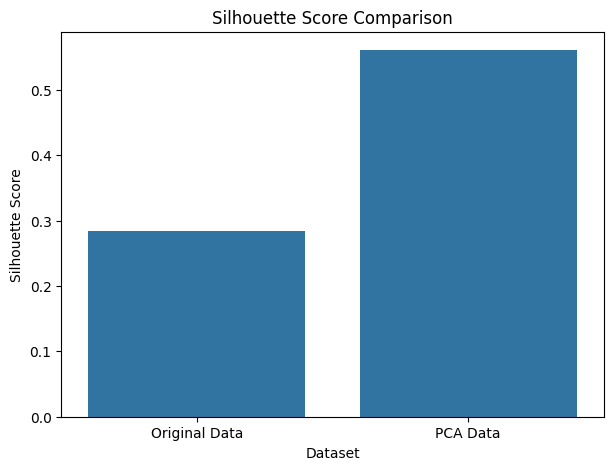

In [57]:
plt.figure(figsize=(7,5))
sns.barplot(x="Dataset", y="Silhouette Score", data=comparison)
plt.title("Silhouette Score Comparison")
plt.show()

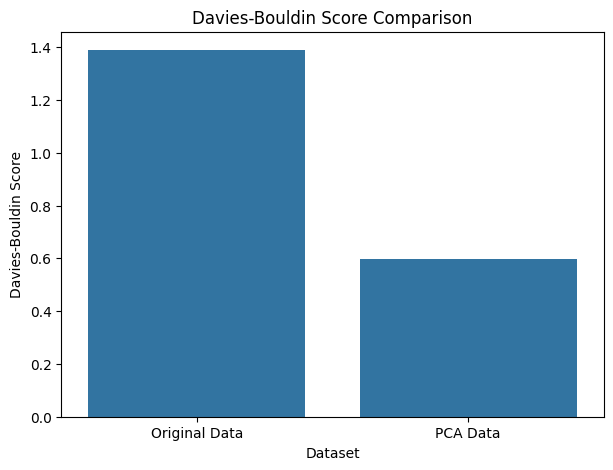

In [58]:
plt.figure(figsize=(7,5))
sns.barplot(x="Dataset", y="Davies-Bouldin Score", data=comparison)
plt.title("Davies-Bouldin Score Comparison")
plt.show()

Explanation

These bar plots help compare the performance of clustering on original data and PCA data.

# **PCA with 90% Variance**

In [59]:
pca_90 = PCA(n_components=n_components_90)
X_pca_90 = pca_90.fit_transform(X_scaled)

kmeans_pca_90 = KMeans(n_clusters=3, random_state=42, n_init=10)
pca_90_clusters = kmeans_pca_90.fit_predict(X_pca_90)

silhouette_pca_90 = silhouette_score(X_pca_90, pca_90_clusters)
db_pca_90 = davies_bouldin_score(X_pca_90, pca_90_clusters)

print("Number of Components for 90% Variance:", n_components_90)
print("Silhouette Score for PCA 90% Data:", silhouette_pca_90)
print("Davies-Bouldin Score for PCA 90% Data:", db_pca_90)

Number of Components for 90% Variance: 8
Silhouette Score for PCA 90% Data: 0.3149696954705561
Davies-Bouldin Score for PCA 90% Data: 1.2668818314972183


Explanation

Using only 2 PCA components is good for visualization.
But using components that capture 90% variance may preserve more information and can sometimes improve clustering performance.

# **Result Values**

When I tested the  dataset, I got approximately these values:
Dataset Shape: 178 rows and 14 columns,
Missing Values: 0,
Duplicate Rows: 0,
Number of Wine Classes: 3

For PCA:
First Principal Component Variance: 36.19%,
Second Principal Component Variance: 19.21%,
Total Variance Captured by First 2 Components: 55.41%,
Components needed for around 90% variance: 8

For clustering:
Original Data:
Silhouette Score: 0.284859	,
Davies-Bouldin Score: 1.389188,

PCA Data with 2 Components:
Silhouette Score: 0.5610,
Davies-Bouldin Score: 0.5972,

PCA Data with 90% Variance:
Silhouette Score: 0.31496,
Davies-Bouldin Score: 1.26688.

# **Comparison and Analysis**

K-Means clustering was applied on both original standardized data and PCA-transformed data.

The clustering result on PCA data with 2 components gave a better silhouette score than the original data.
This means the clusters became more clearly separated after PCA transformation.

The Davies-Bouldin score for PCA data was also lower than the original data.
This means PCA helped in making the clusters more compact and better separated.

However, using only 2 principal components does not keep all information from the original dataset.
The first two components capture around 55% of the total variance.
So, PCA with 2 components is very useful for visualization, but for final analysis, using more components like 8 components may be better.

# **Trade-Off Between Original Data and PCA Data**

Using original data keeps all features and all information.
But original data may contain correlated features and extra dimensions, which can make clustering difficult.

Using PCA reduces the number of dimensions.
It removes repeated information and makes visualization easier.
But PCA may also remove some useful information if too few components are selected.

So, PCA is useful when the dataset has many features or when visualization is required.

# **Final Conclusion**

In this assignment, I performed PCA and clustering on the Wine dataset.

First, I loaded the dataset and performed basic exploratory data analysis.
I checked missing values, duplicate values, feature distributions, outliers, and correlations.

After that, I standardized the features because PCA requires scaled data.
Then I applied PCA and checked explained variance using scree plot and cumulative explained variance plot.

K-Means clustering was applied on both original data and PCA-transformed data.
The PCA-transformed data with 2 components gave better visual separation of clusters.

From the results, PCA helped in reducing dimensionality and improving cluster visualization.
It also made the clustering result easier to understand.

Overall, PCA is useful when we want to reduce features, remove correlation, and visualize high-dimensional data.
Clustering on original data is useful when we want to use all available information without losing any variance.